In [1]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv")
df.head(5)

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [5]:
df['category'].value_counts()

category
 1    15830
 0    13142
-1     8277
Name: count, dtype: int64

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df[df['clean_comment'].str.strip() == '']

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [9]:
df = df[~(df['clean_comment'].str.strip() == '')]

In [10]:
df['clean_comment'] = df['clean_comment'].str.lower()

In [11]:
df.head(3)

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1


In [16]:
df[df['clean_comment'].fillna('').apply(lambda x: x.endswith(' ') or x.startswith(' '))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [19]:
df['clean_comment'] = df['clean_comment'].str.strip()
df.fillna('', inplace=True)

In [20]:
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = df[df['clean_comment'].str.contains(url_pattern, regex=True)]

In [21]:
comments_with_urls

,clean_comment,category


In [22]:
df['clean_comment'] = df['clean_comment'].str.replace('\n', ' ', regex=True)

In [27]:
df[df['category'] == '']

,clean_comment,category


<Axes: xlabel='category', ylabel='count'>

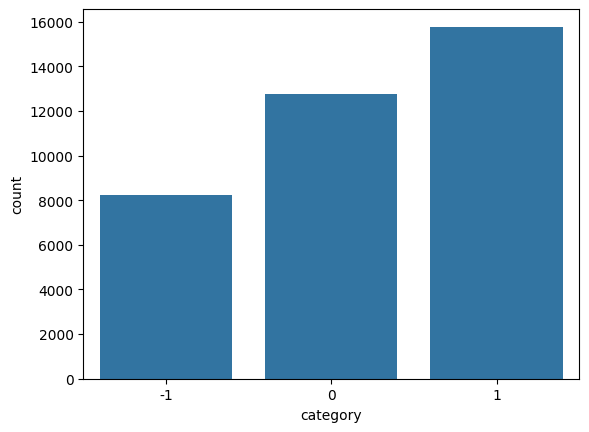

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='category', data=df)

In [29]:
df['category'].value_counts(normalize=True)

category
 1    0.428630
 0    0.347149
-1    0.224221
Name: proportion, dtype: float64

In [30]:
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))

In [31]:
df['word_count'].describe()

count    36794.000000
mean        29.666658
std         56.790177
min          0.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: word_count, dtype: float64

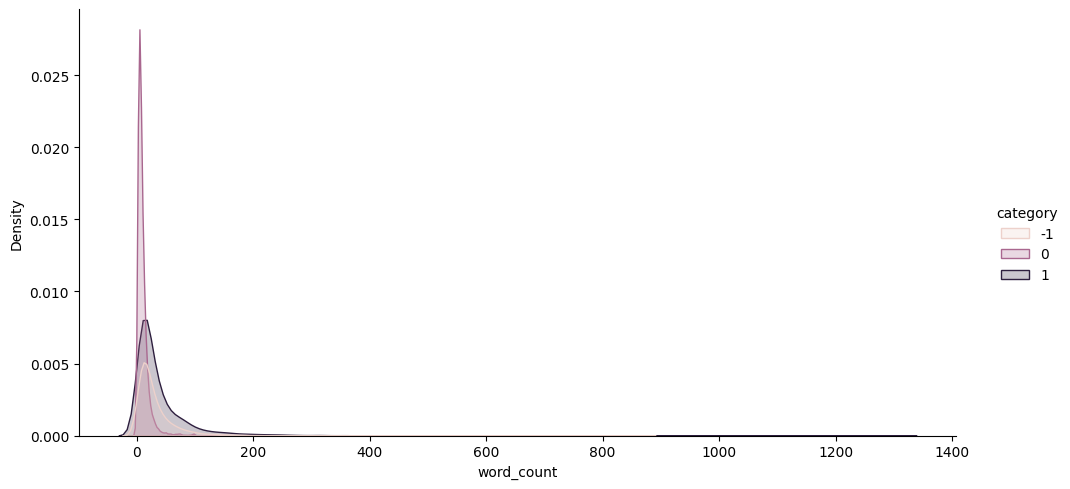

In [33]:
sns.displot(data=df, x='word_count', hue='category', kind='kde', fill=True, height=5, aspect=2)

In [34]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['num-stopwords'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [35]:
df['num-stopwords'].describe()

count    36794.000000
mean         9.839811
std         19.381131
min          0.000000
25%          1.000000
50%          4.000000
75%         10.000000
max        463.000000
Name: num-stopwords, dtype: float64

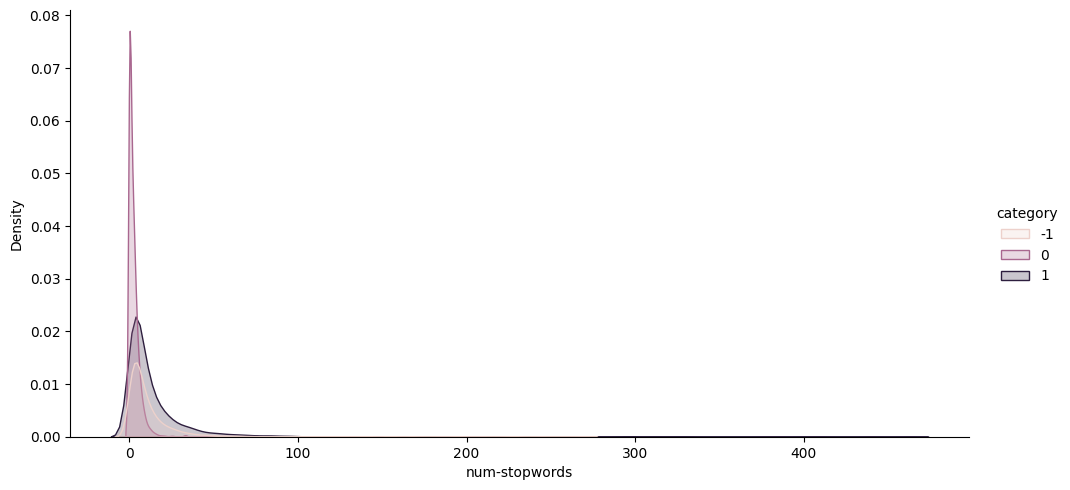

In [38]:
sns.displot(data=df, x='num-stopwords', hue='category', kind='kde', fill=True, height=5, aspect=2)

In [40]:
stop_words = set(stopwords.words('english')) - {'not','no','but','however','against','nor','don','ain','aren','couldn','didn','doesn','hadn','hasn','haven','isn','yet'}

df['clean_comment'] = df['clean_comment'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))


In [41]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['clean_comment'] = df['clean_comment'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))